In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/CursoPINN-CEIA-UBA/20253B/Material didáctico/Modulo6

/content/drive/MyDrive/CursoPINN-CEIA-UBA/20253B/Material didáctico/Modulo6


# PI-DeepONets sin datos rotulados

## Definición de las redes "branch" y "trunk", y de la DeepONet

In [ ]:
# Define the Branch Network
class BranchNet(nn.Module):
    def __init__(self, branchNet_params):
        super(BranchNet, self).__init__()
        self.Device = branchNet_params["Device"]
        self.InputDimensions = branchNet_params["InputDimensions"]
        self.OutputDimensions = branchNet_params["OutputDimensions"]
        self.NumberOfNeurons = branchNet_params["NumberOfNeurons"]
        self.NumberOfHiddenLayers = branchNet_params["NumberOfHiddenLayers"]
        self.ActivationFunction = branchNet_params["ActivationFunction"]
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)
        self.init_xavier()

    def forward(self, x):
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output

    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                # gain = nn.init.calculate_gain('tanh')
                gain = 1
                torch.nn.init.xavier_uniform_(m.weight, gain=gain)
                torch.nn.init.uniform_(m.bias, 0, 1)

        self.apply(init_weights)

# Define the Trunk Network
class TrunkNet(nn.Module):
    def __init__(self, trunkNet_params):
        super(TrunkNet, self).__init__()
        self.Device = trunkNet_params["Device"]
        self.InputDimensions = trunkNet_params["InputDimensions"]
        self.OutputDimensions = trunkNet_params["OutputDimensions"]
        self.NumberOfNeurons = trunkNet_params["NumberOfNeurons"]
        self.NumberOfHiddenLayers = trunkNet_params["NumberOfHiddenLayers"]
        self.ActivationFunction = trunkNet_params["ActivationFunction"]
        self.InputLayer = nn.Linear(self.InputDimensions, self.NumberOfNeurons)
        self.HiddenLayers = nn.ModuleList(
            [nn.Linear(self.NumberOfNeurons, self.NumberOfNeurons) for _ in range(self.NumberOfHiddenLayers - 1)])
        self.OutputLayer = nn.Linear(self.NumberOfNeurons, self.OutputDimensions)
        self.init_xavier()

    def forward(self, x):
        output = self.ActivationFunction(self.InputLayer(x))
        for k, l in enumerate(self.HiddenLayers):
            output = self.ActivationFunction(l(output))
        output = self.OutputLayer(output)
        return output

    def init_xavier(self):
        def init_weights(m):
            if type(m) == nn.Linear and m.weight.requires_grad and m.bias.requires_grad:
                # gain = nn.init.calculate_gain('tanh')
                gain = 1
                torch.nn.init.xavier_uniform_(m.weight, gain=gain)
                torch.nn.init.uniform_(m.bias, 0, 1)

        self.apply(init_weights)


# Define the DeepONet
class DeepONet(nn.Module):
    def __init__(self, branch_net, trunk_net):
        super(DeepONet, self).__init__()
        self.branch_net = branch_net
        self.trunk_net = trunk_net

    def forward(self, branch_input, trunk_input):
        # Get branch and trunk outputs
        branch_output = self.branch_net(branch_input)  # Shape: [batch_size, branch_output_dim]
        trunk_output = self.trunk_net(trunk_input)    # Shape: [batch_size, trunk_output_dim]

        # Combine the outputs (dot product across the last dimension)
        combined_output = torch.sum(branch_output*trunk_output, dim=-1).view(-1, 1)
        return combined_output


## Initialization

In [ ]:
# Initialization parameters
branchNet_params = {
    "Device": device,
    "InputDimensions": 100,
    "OutputDimensions": 100,
    "NumberOfNeurons": 100,
    "NumberOfHiddenLayers": 2,
    "ActivationFunction": nn.GELU()
}

trunkNet_params = {
    "Device": device,
    "InputDimensions": 1,
    "OutputDimensions": 100,
    "NumberOfNeurons": 100,
    "NumberOfHiddenLayers": 2,
    "ActivationFunction": nn.GELU()
}

In [ ]:
# Download training data
d = np.load("antiderivative_unaligned_train.npz", allow_pickle=True)
v_train = torch.from_numpy(d["X_train0"]).to(torch.float32).to(device)
x_train = torch.from_numpy(d["X_train1"]).to(torch.float32).to(device)
u_train = torch.from_numpy(d["y_train"]).to(torch.float32).to(device)

print("Shape of v_train: ", v_train.shape)
print("Shape of x_train: ", x_train.shape)
print("Shape of u_train: ", u_train.shape)

# Download testing data
d = np.load("antiderivative_unaligned_test.npz", allow_pickle=True)
v_test = torch.from_numpy(d["X_test0"]).to(torch.float32).to(device)
x_test = torch.from_numpy(d["X_test1"]).to(torch.float32).to(device)
u_test = torch.from_numpy(d["y_test"]).to(torch.float32).to(device)

print("Shape of v_test: ", v_test.shape)
print("Shape of x_test: ", x_test.shape)
print("Shape of u_test: ", u_test.shape)

idx_test = np.random.choice(len(x_test), 100, replace=False)

Shape of v_train:  torch.Size([10000, 100])
Shape of x_train:  torch.Size([10000, 1])
Shape of u_train:  torch.Size([10000, 1])
Shape of v_test:  torch.Size([100000, 100])
Shape of x_test:  torch.Size([100000, 1])
Shape of u_test:  torch.Size([100000, 1])


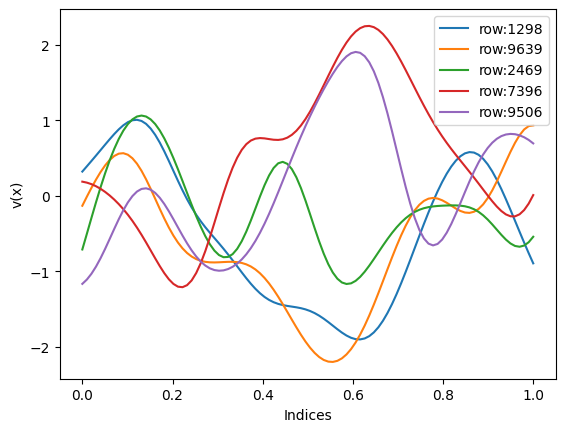

In [ ]:
rows = np.random.randint(0, 10000, 5)
for row in rows:
    plt.plot(np.linspace(0.0, 1.0, v_train.shape[1]), v_train[row, :].data.cpu().detach().numpy(), label=f'row:{row}')

plt.xlabel('Indices')
plt.ylabel('v(x)')
plt.legend()
plt.show()

## Main

In [ ]:
# Build model
branch_net = BranchNet(branchNet_params).to(device)
trunk_net = TrunkNet(trunkNet_params).to(device)
model = DeepONet(branch_net, trunk_net).to(device)

In [ ]:
def interpolate_batch(v_train, x_train, device):
    N, M = v_train.shape
    x_grid = torch.linspace(0, 1, M, device=device)  # [M]
    dx = x_grid[1] - x_grid[0]  # assuming uniform spacing

    # Clamp x_train to [0, 1]
    x_clamped = torch.clamp(x_train, 0.0, 1.0)

    # Compute the left index of the interpolation interval for each x
    idx = torch.floor(x_clamped / dx).long()  # shape: [N, K]
    idx = torch.clamp(idx, 0, M - 2)  # ensure idx+1 does not go out of bounds

    # Gather left and right y values
    v_left = torch.gather(v_train, 1, idx)           # shape: [N, K]
    v_right = torch.gather(v_train, 1, idx + 1)       # shape: [N, K]

    # Compute weights
    x_left = idx.float() * dx  # [N, K]
    alpha = (x_clamped - x_left) / dx  # fractional distance between grid points

    # Linear interpolation
    v_interp = (1 - alpha) * v_left + alpha * v_right  # [N, K]
    return v_interp


In [ ]:
# Physics-Informed Training Loop
epochs = 20000
optimizer = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=500, tolerance_grad=1e-9, tolerance_change=1e-9)
criterion = nn.MSELoss()

train_err_list = []
train_loss_list = []
test_err_list = []
test_loss_list = []

x_train.requires_grad = True

# For enforcing u(0) = 0
x0 = torch.zeros_like(x_train[:, :1]).to(device)

def closure():
    optimizer.zero_grad()
    u_pred = model(v_train, x_train)
    u_pred.requires_grad_(True)
    u_pred_grad = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_train,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True
    )[0]
    v_x = interpolate_batch(v_train, x_train, device)
    residual = u_pred_grad - v_x
    loss_pde = torch.mean(residual**2)
    u0_pred = model(v_train, x0)
    loss_bc = torch.mean((u0_pred - 0.0)**2)
    loss = loss_pde + loss_bc
    loss.backward()
    return loss


for epoch in range(epochs):
    model.train()

    optimizer.step(closure)

    # Compute model prediction u(x)
    u_pred = model(v_train, x_train)  # Shape: [N, 1]

    # Compute du/dx using autograd
    u_pred.requires_grad_(True)
    u_pred_grad = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_train,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True
    )[0]

    # Residual of the ODE: du/dx - v(x) = 0
    v_x = interpolate_batch(v_train, x_train, device)
    residual = u_pred_grad - v_x

    # Compute loss: ODE residual + boundary condition
    loss_pde = torch.mean(residual**2)

    # Enforce boundary condition u(0) = 0
    u0_pred = model(v_train, x0)
    loss_bc = torch.mean((u0_pred - 0.0)**2)

    train_loss = loss_pde + loss_bc

    # Relative error tracking
    train_err = torch.linalg.norm((u_pred - u_train).detach(), dim=1) / torch.linalg.norm(u_train.detach(), dim=1)
    train_err_list.append(train_err.mean().item())
    train_loss_list.append(train_loss.item())

    # Test stage
    model.eval()
    with torch.no_grad():
        u_test_pred = model.forward(v_test[idx_test, :], x_test[idx_test, :])
        test_loss = torch.mean((u_test_pred - u_test[idx_test, :])**2)
        test_err = torch.linalg.norm((u_test[idx_test, :] - u_test_pred).detach(), dim=1)/\
                    torch.linalg.norm(u_test[idx_test, :].detach(), dim=1)
        test_err_list.append(test_err.mean().item())
        test_loss_list.append(test_loss.item())


    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}, Training ODE Loss: {loss_pde.item():.6f}, Training BC Loss: {loss_bc.item():.6f}")
        print(f"Epoch {epoch+1}, Test Loss: {test_loss:.6f}")

Epoch 1, Training ODE Loss: 0.352206, Training BC Loss: 0.000324
Epoch 1, Test Loss: 0.029103


KeyboardInterrupt: 

In [ ]:
# Physics-Informed Training Loop
epochs = 20000
lr = 1e-4
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

train_err_list = []
train_loss_list = []
test_err_list = []
test_loss_list = []

x_train.requires_grad = True

# For enforcing u(0) = 0
x0 = torch.zeros_like(x_train[:, :1]).to(device)

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Compute model prediction u(x)
    u_pred = model(v_train, x_train)  # Shape: [N, 1]

    # Compute du/dx using autograd
    u_pred.requires_grad_(True)
    u_pred_grad = torch.autograd.grad(
        outputs=u_pred,
        inputs=x_train,
        grad_outputs=torch.ones_like(u_pred),
        create_graph=True,
        retain_graph=True
    )[0]

    # Residual of the ODE: du/dx - v(x) = 0
    v_x = interpolate_batch(v_train, x_train, device) # Interpolate each v_train sample in all x_train points
    residual = u_pred_grad - v_x

    # Compute loss: ODE residual + boundary condition
    loss_pde = torch.mean(residual**2)

    # Enforce boundary condition u(0) = 0
    u0_pred = model(v_train, x0)
    loss_bc = torch.mean((u0_pred - 0.0)**2)

    train_loss = loss_pde + loss_bc

    # Backpropagation
    train_loss.backward()
    optimizer.step()

    # Relative error tracking
    train_err = torch.linalg.norm((u_pred - u_train).detach(), dim=1) / torch.linalg.norm(u_train.detach(), dim=1)
    train_err_list.append(train_err.mean().item())
    train_loss_list.append(train_loss.item())

    # Test stage
    model.eval()
    with torch.no_grad():
        u_test_pred = model.forward(v_test[idx_test, :], x_test[idx_test, :])
        test_loss = torch.mean((u_test_pred - u_test[idx_test, :])**2)
        test_err = torch.linalg.norm((u_test[idx_test, :] - u_test_pred).detach(), dim=1)/\
                    torch.linalg.norm(u_test[idx_test, :].detach(), dim=1)
        test_err_list.append(test_err.mean().item())
        test_loss_list.append(test_loss.item())


    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}, Training ODE Loss: {loss_pde.item():.6f}, Training BC Loss: {loss_bc.item():.6f}")
        print(f"Epoch {epoch+1}, Test Loss: {test_loss:.6f}")


Epoch 1, Training ODE Loss: 4.046575, Training BC Loss: 1231.195190
Epoch 1, Test Loss: 1090.530762
Epoch 101, Training ODE Loss: 1.658756, Training BC Loss: 8.852740
Epoch 101, Test Loss: 10.542843
Epoch 201, Training ODE Loss: 1.005492, Training BC Loss: 4.339098
Epoch 201, Test Loss: 4.802177
Epoch 301, Training ODE Loss: 0.898419, Training BC Loss: 2.401081
Epoch 301, Test Loss: 2.496007
Epoch 401, Training ODE Loss: 0.850033, Training BC Loss: 1.502906
Epoch 401, Test Loss: 1.546015
Epoch 501, Training ODE Loss: 0.824428, Training BC Loss: 1.058353
Epoch 501, Test Loss: 1.119538
Epoch 601, Training ODE Loss: 0.808744, Training BC Loss: 0.811854
Epoch 601, Test Loss: 0.889527
Epoch 701, Training ODE Loss: 0.797713, Training BC Loss: 0.656993
Epoch 701, Test Loss: 0.740694
Epoch 801, Training ODE Loss: 0.789055, Training BC Loss: 0.549679
Epoch 801, Test Loss: 0.632967
Epoch 901, Training ODE Loss: 0.781725, Training BC Loss: 0.470207
Epoch 901, Test Loss: 0.550242
Epoch 1001, Train

## Plotting

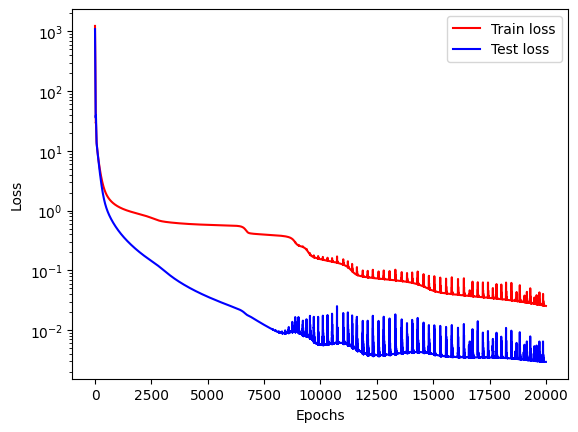

In [ ]:
# Losses
plt.semilogy(np.arange(epochs), train_loss_list, color='r', label='Train loss')
plt.semilogy(np.arange(epochs), test_loss_list, color='b', label='Test loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

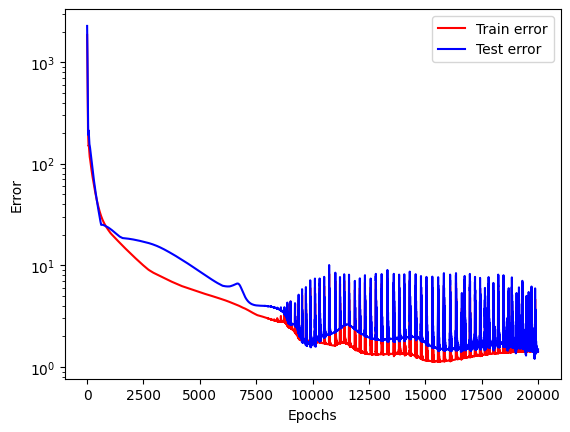

In [ ]:
# L2 errors
plt.semilogy(np.arange(epochs), train_err_list, color='r', label='Train error')
plt.semilogy(np.arange(epochs), test_err_list, color='b', label='Test error')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Error')
plt.show()

## Predictions

In [ ]:
x_trial = torch.linspace(0, 1, 100).requires_grad_(True).to(device)
f = lambda x: 1/(2*np.pi)*torch.sin(2*np.pi*x) # A function f that f(0)=0
u_trial = f(x_trial)
v_trial = torch.autograd.grad(outputs=u_trial, inputs=x_trial, grad_outputs=torch.ones_like(u_trial), create_graph=True)[0]
u_pred = model.forward(v_trial.repeat(100, 1), x_trial.view(-1, 1))

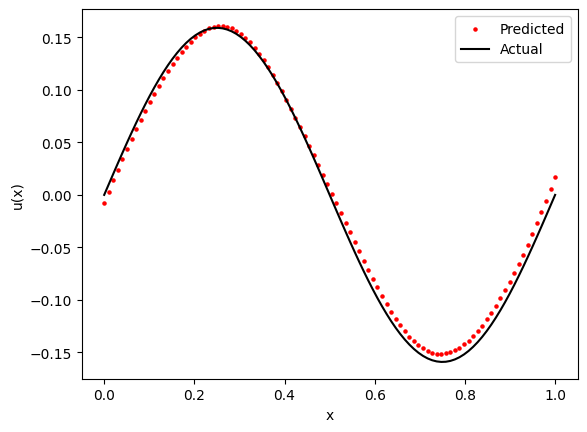

In [ ]:
plt.scatter(np.linspace(0, 1, 100), u_pred.data.cpu().detach().numpy(), s=5, color='r', label='Predicted')
plt.plot(np.linspace(0, 1, 100), f(torch.linspace(0, 1, 100)), color='k', label='Actual')
plt.legend()
plt.xlabel('x')
plt.ylabel('u(x)')
plt.show()

In [ ]:
x_trial = torch.linspace(0, 1, 100).requires_grad_(True).to(device)
f = lambda x: -(x - 0.5)**2 + 0.25
u_trial = f(x_trial)
v_trial = torch.autograd.grad(outputs=u_trial, inputs=x_trial, grad_outputs=torch.ones_like(u_trial), create_graph=True)[0]
u_pred = model.forward(v_trial.repeat(100, 1), x_trial.view(-1, 1))

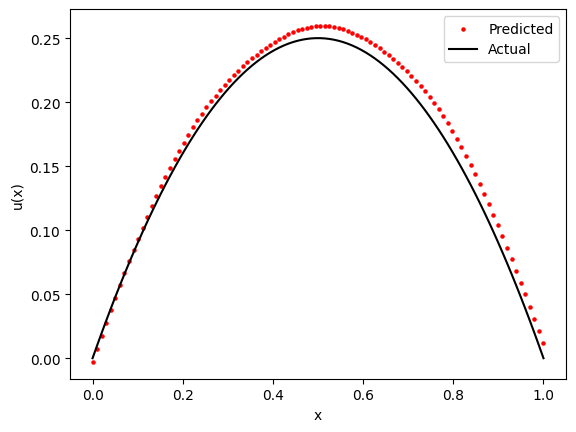

In [ ]:
plt.scatter(np.linspace(0, 1, 100), u_pred.data.cpu().detach().numpy(), s=5, color='r', label='Predicted')
plt.plot(np.linspace(0, 1, 100), f(torch.linspace(0, 1, 100)), color='k', label='Actual')
plt.legend()
plt.xlabel('x')
plt.ylabel('u(x)')
plt.show()